In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')
from CEmulator.Emulator import CBaseEmulator
csstemu = CBaseEmulator(verbose=True) # default neutrino_mass_split='single'

Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.


In [2]:
Ob = 0.05
Oc = 0.25
h = 0.7
ns = 0.96
As = 2.1e-9
w0 = -1
wa = 0
mnu = 0.06
csstemu.set_cosmos(Omegab=Ob, Omegac=Oc, As=As, mnu=mnu,
                   H0=h*100, ns=ns, w=w0, wa=wa)

In [3]:
zarr  = np.linspace(0, 3, 10000)
%time chi_0 = csstemu.Cosmo.comoving_distance(zarr, neutrino_matter_like=False)

CPU times: user 3.32 ms, sys: 114 µs, total: 3.44 ms
Wall time: 3.11 ms


In [4]:
### assume massive neutrinos behave like matter at all redshifts, can get a faster calculation
%time chi_1 = csstemu.Cosmo.comoving_distance(zarr, neutrino_matter_like=True)

CPU times: user 2.45 ms, sys: 531 µs, total: 2.99 ms
Wall time: 2.65 ms


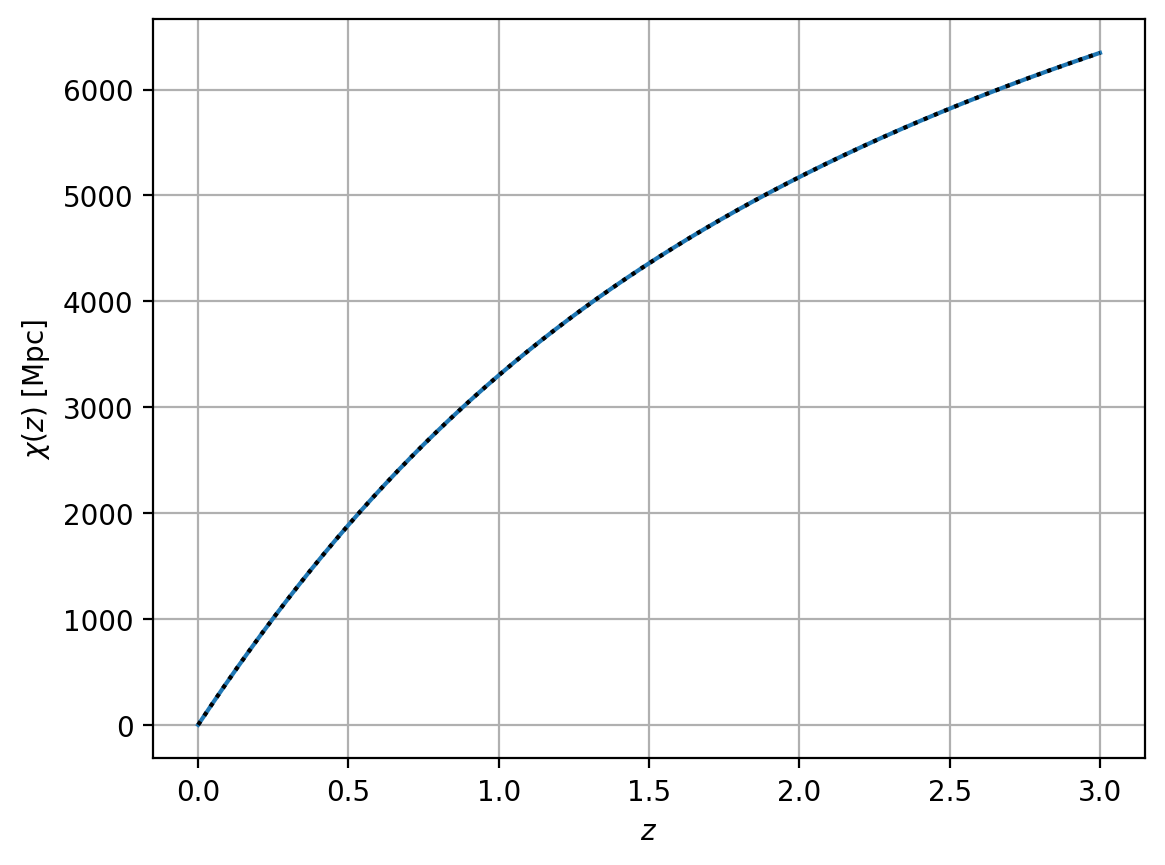

In [5]:
plt.plot(zarr, chi_0)
plt.plot(zarr, chi_1, "k:")
plt.xlabel(r"$z$")
plt.ylabel(r"$\chi(z)$ [Mpc]")
plt.grid(True)

In [6]:
np.max((chi_0-chi_1)[chi_0!=0]/chi_0[chi_0!=0])

1.5350091944207382e-05